In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
# local mods
import geo_utils as geo
import clean_utils as clean


In [2]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np
import joblib
from pathlib import Path

In [3]:
import random

In [45]:
# Path to the folder containing spreadsheet files
#path = "spreadsheets/*.csv"
#path = "test1/*.xlsx"
#path = "test3/*.xlsx"
#path = "test5/*.xlsx"
path = "data/raw/test2026-06-13/*.xlsx"

In [46]:
files = glob.glob(path)

# Load each file into a list of DataFrames
df_list = [pd.read_excel(file) for file in files]

# Combine them into one master DataFrame and drop na
master_df = pd.concat(df_list, ignore_index=True)
master_df = master_df.dropna(subset=["intersection","text_on_sign_exact"])

In [47]:
# clean the strings so they have punctuation removed and such
master_df = clean.clean_string_columns(master_df,columns=["text_on_sign_exact"])

In [ ]:
# import additional data for mapping coordinates to intersection names
coordinates = pd.read_csv("data/raw/coordinate_dict/coordinate_dict2026-06-13.csv")
platte_river_points = pd.read_csv("data/raw/platte_points.csv")

In [49]:
# drop na and transition latitude and longitude strings
# to a float format
coordinates[["latitude", "longitude"]] = (
    coordinates["cd"]
    .dropna()
    .apply(geo.parse_dms_coordinate)
    .apply(pd.Series)
)

In [50]:
# merge the coordinate sheet with the master sheet
# so the data can be trained
training_data_raw = master_df.merge(
    coordinates[["intersection", "latitude", "longitude", "zip", "city"]],
    on="intersection",
    how="left"
)

In [75]:
training_data_raw

,intersection,text_on_sign_exact,code_type,notes,Unnamed: 3,latitude,longitude,zip,city
0,florida-federal,federal,street_sign,NaN,NaN,39.689500,-105.025028,NaN,sheridan
1,florida-federal,uper ave,advertisement,NaN,NaN,39.689500,-105.025028,NaN,sheridan
2,florida-federal,federal village,advertisement,NaN,NaN,39.689500,-105.025028,NaN,sheridan
3,florida-federal,vs liquors,advertisement,NaN,NaN,39.689500,-105.025028,NaN,sheridan
4,florida-federal,dollar general,storefront_accessory,NaN,NaN,39.689500,-105.025028,NaN,sheridan
...,...,...,...,...,...,...,...,...,...
3854,20th-blake,public parking,NaN,NaN,NaN,39.754361,-104.994250,NaN,NaN
3855,20th-blake,express lane hov 3 no toll with expresstoll,NaN,NaN,NaN,39.754361,-104.994250,NaN,NaN
3856,20th-blake,express lane,NaN,NaN,NaN,39.754361,-104.994250,NaN,NaN
3857,20th-blake,20th st 2000,NaN,NaN,NaN,39.754361,-104.994250,NaN,NaN


In [52]:
# create a dataframe that has one row per instersection with
# all of the text combined for that intersection
intersection_df = (
    training_data_raw
    .groupby("intersection")
    .agg({
        "text_on_sign_exact": " ".join,
        "latitude": "first",
        "longitude": "first",
        "zip": "first",
        "city": "first"
    })
    .reset_index()
    .rename(columns={"text_on_sign_exact": "text_blob"})
)

In [53]:
# remove intersections where geographical data has not been completed
intersection_df = intersection_df.dropna(subset=["latitude","longitude"])
# create a checkpoint dataset

In [54]:
coords = intersection_df[["latitude", "longitude"]]

# perform k-means clustering on the coordinates
# for optional classification algorithm later on
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")

intersection_df["spatial_cluster"] = kmeans.fit_predict(coords)

In [55]:
intersection_df

,intersection,text_blob,latitude,longitude,zip,city,spatial_cluster
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,2
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,1
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,1
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora,1
6,14th-broadway,only one way open during constrcution library ...,39.738472,-104.987444,80202.0,denver,2
...,...,...,...,...,...,...,...
122,quincy-broadway,dip yamaha home theater parasound open marantz...,39.638583,-104.987806,80113.0,englewood,0
123,tennessee-federal,novacane tony pho miracle touch kim son jewele...,39.698611,-105.025083,NaN,sheridan,2
124,tufts-broadway,lucky u motel 4575 office ace hardware welcome...,39.633139,-104.987861,80113.0,englewood,0
125,victorian-mainstreet,park sixty four no parking any time 2 hour par...,39.518111,-104.759889,80138.0,parker,3


In [56]:
#intersection_df = intersection_df[
#    intersection_df["city"].isin(["denver", "englewood", "cherry creek", "aurora"])
#]

In [59]:
intersection_df

,intersection,text_blob,latitude,longitude,zip,city,spatial_cluster
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,2
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,1
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,1
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora,1
6,14th-broadway,only one way open during constrcution library ...,39.738472,-104.987444,80202.0,denver,2
...,...,...,...,...,...,...,...
122,quincy-broadway,dip yamaha home theater parasound open marantz...,39.638583,-104.987806,80113.0,englewood,0
123,tennessee-federal,novacane tony pho miracle touch kim son jewele...,39.698611,-105.025083,NaN,sheridan,2
124,tufts-broadway,lucky u motel 4575 office ace hardware welcome...,39.633139,-104.987861,80113.0,englewood,0
125,victorian-mainstreet,park sixty four no parking any time 2 hour par...,39.518111,-104.759889,80138.0,parker,3


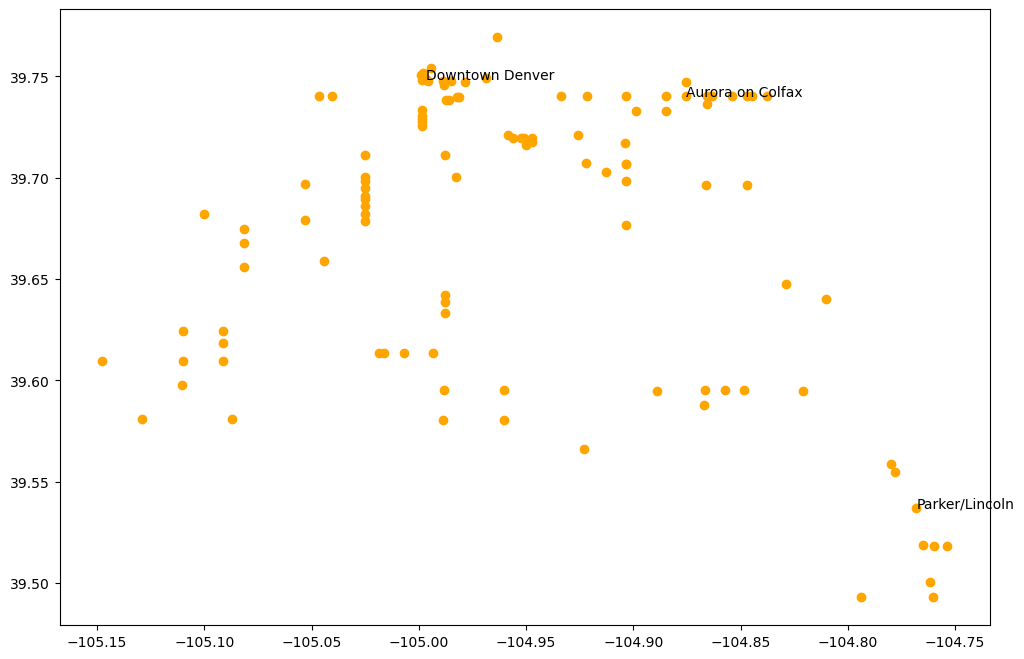

In [60]:
plt.figure(figsize=(12,8))

plt.text(-104.996583333333, 39.74852777777778,"Downtown Denver")
plt.text(-104.875277777777, 39.74022222222222, "Aurora on Colfax")
plt.text(-104.768055555555, 39.53711111111111, "Parker/Lincoln")

plt.scatter(
    intersection_df["longitude"], 
    intersection_df["latitude"], 
    color = "orange", 
    label = "Trained Intersections")
plt.show()

# Predicting a Single Coordinate Based on Language Data from an Intersection
## Distance

In [61]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two points on Earth.
    
    Returns distance in kilometers.
    """

    R = 6371  # Earth radius in km

    # convert degrees to radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # haversine formula
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [62]:
# set up dataset of optional data training process
training_data = training_data_raw.dropna(subset=["latitude","longitude"])

In [63]:
# create function that will create a sample training dataset
# based on random combinations of linguistic landscape observations
def generate_samples(signs, n_samples=50,
                     min_size=3,
                     max_size=7,
                     seed=None):

    rng = random.Random(seed)
    samples = []

    for _ in range(n_samples):

        lower = min(min_size, len(signs))
        upper = min(max_size, len(signs))

        size = rng.randint(lower, upper)
        subset = rng.sample(signs, size)

        samples.append(" ".join(subset))

    return samples

In [64]:
# create random sample with the training data
augmented_rows = []
seed = 42

for intersection, group in training_data.groupby("intersection"):
    
    signs = group["text_on_sign_exact"].dropna().tolist()
    
    lat = group["latitude"].iloc[0]
    lon = group["longitude"].iloc[0]
    
    samples = generate_samples(
        signs,
        n_samples=50,
        min_size=5,
        max_size=10,
        seed=seed
    )
    seed += 1
    
    for sample in samples:
        augmented_rows.append({
            "intersection": intersection,
            "sample_text": sample,
            "lat": lat,
            "lon": lon
        })

In [65]:
test = pd.DataFrame(augmented_rows)
test

,intersection,sample_text,lat,lon
0,11th-santafe,711 gas is 329 armstrong dance center hyder co...,39.733667,-104.998694
1,11th-santafe,sante fe theater armstrong dance center swifts...,39.733667,-104.998694
2,11th-santafe,tacos selene swifts breakfeast aztlan denver w...,39.733667,-104.998694
3,11th-santafe,nicks studio brick building nita sante fe thea...,39.733667,-104.998694
4,11th-santafe,tacos selene quin 711 gas is 329 aztlan sante ...,39.733667,-104.998694
...,...,...,...,...
5595,yale-wadsworth,stanley steemer stanley steemer lazboy wild bi...,39.667778,-105.081472
5596,yale-wadsworth,wild birds unlimited wild birds unlimited lazb...,39.667778,-105.081472
5597,yale-wadsworth,stanley steemer wild birds unlimited stanley s...,39.667778,-105.081472
5598,yale-wadsworth,lazboy lazboy stanley steemer stanley steemer ...,39.667778,-105.081472


In [66]:
# assign variables based on original dataset
X = intersection_df["text_blob"]

# for using geographical coordinates
y = intersection_df[["latitude", "longitude"]]

# for using kmean clusters
# y = intersection_df["spatial_cluster"]   # or "city", "region_label", etc.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= 348#24#2 # 55 #46 # 42
)

In [68]:
coord_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        lowercase=True,
        min_df=2
    )),
    ("regressor", MultiOutputRegressor(
        Ridge(alpha=0.1)
    ))
])

In [69]:
X_test

72     olive garden 2nd and charles fontana sushi top...
118    in n out pine parker spa brokers golf carts mu...
29     3rd ave stop speed limit 25 over 7000 lbs empt...
20     coors field one way blake st 1500 one way noti...
98     dickerson family market farmers market good fe...
32     tribe tattoo denver public library thunderbird...
31     the pza pizzeria pizza closed colorado histori...
52     emergency natural grocers lowest cigarette pri...
30     d denver josephine st one way one way d denver...
60     moline corner store coffee phone cards donuts ...
22     gamma gallery lemonade house 23 clearance 70 g...
83     federal uper ave federal village vs liquors do...
99     littleton museum bacon social house cherry cri...
106    walgreens right lane must turn right shotokan ...
19     midfirst bank key bank 1st ave cook st olive f...
78     macys steel st ellsworth ave turning vehicals ...
50     dairy queen big o tires tacos selene hotpot de...
88     propane fast fill fast p

In [70]:
# fit the model
# model.fit(X_train, y_train)
coord_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char', min_df=2,
                                 ngram_range=(2, 5))),
                ('regressor',
                 MultiOutputRegressor(estimator=Ridge(alpha=0.1)))])

In [71]:
Path("models").mkdir(exist_ok=True)

coord_model.fit(X_train, y_train)

joblib.dump(coord_model, "models/coord_model.joblib")

['models/coord_model.joblib']

In [72]:
# test out the training data
pred_coords = coord_model.predict(X_test)

pred_df = y_test.copy()
pred_df["pred_latitude"] = pred_coords[:, 0]
pred_df["pred_longitude"] = pred_coords[:, 1]

pred_df.head()

,latitude,longitude,pred_latitude,pred_longitude
72,39.618361,-105.091222,39.673683,-104.986017
118,39.500306,-104.761861,39.622742,-104.948756
29,39.721028,-104.925806,39.687400,-104.972085
20,39.754361,-104.994250,39.702791,-104.967884
98,39.613278,-104.993167,39.667607,-104.977009


In [73]:
# assigning mins and maxs to set bounds for random points
lat_min = min(pred_df["latitude"].min(), pred_df["pred_latitude"].min())
lat_max = max(pred_df["latitude"].max(), pred_df["pred_latitude"].min())
long_min = min(pred_df["longitude"].min(),pred_df["pred_longitude"].min())
long_max = max(pred_df["longitude"].max(), pred_df["longitude"].max())

In [74]:
# create random points for latitude and longitude
np.random.seed(28)

pred_df["random_latitude"] = np.random.uniform(
    lat_min,
    lat_max,
    size=len(pred_df)
)

pred_df["random_longitude"] = np.random.uniform(
    long_min,
    long_max,
    size=len(pred_df)
)

In [39]:
# append random error to spreadsheet
pred_df["random_error_km"] = haversine_distance(
    pred_df["latitude"],
    pred_df["longitude"],
    pred_df["random_latitude"],
    pred_df["random_longitude"]
)

In [40]:
mae_lat = mean_absolute_error(y_test["latitude"], pred_df["pred_latitude"])
mae_lng = mean_absolute_error(y_test["longitude"], pred_df["pred_longitude"])

print("Latitude MAE:", mae_lat)
print("Longitude MAE:", mae_lng)

Latitude MAE: 0.04592962224379446
Longitude MAE: 0.09383305659071924


In [41]:
pred_df["error_km"] = haversine_distance(
    pred_df["latitude"],
    pred_df["longitude"],
    pred_df["pred_latitude"],
    pred_df["pred_longitude"]
)

pred_df[[
    "latitude",
    "longitude",
    "pred_latitude",
    "pred_longitude",
    "error_km"
]].head(7)

,latitude,longitude,pred_latitude,pred_longitude,error_km
74,39.678667,-105.025056,39.653880,-104.922081,9.235020
61,39.740306,-105.046306,39.726982,-105.007179,3.659100
28,39.798306,-104.786917,39.691153,-104.966096,19.407409
19,39.754361,-104.994250,39.690514,-104.968496,7.433359
109,39.500306,-104.761861,39.619933,-104.933563,19.839473
31,39.728944,-104.998583,39.668530,-104.957951,7.563979
30,39.727333,-104.998667,39.698374,-104.980955,3.558689


In [42]:
print("Mean error in km:", pred_df["error_km"].mean())
print("Median error in km:", pred_df["error_km"].median())

Mean error in km: 10.347835344248628
Median error in km: 9.86401589832861


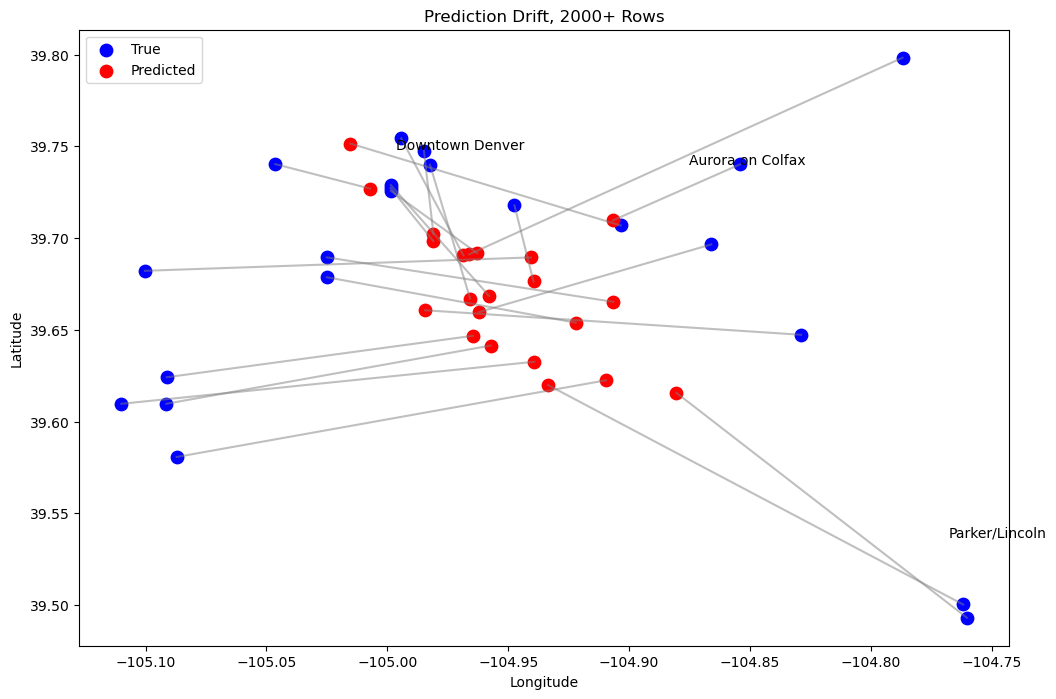

In [43]:
plt.figure(figsize=(12,8))

plt.text(-104.996583333333, 39.74852777777778,"Downtown Denver")
plt.text(-104.875277777777, 39.74022222222222, "Aurora on Colfax")
plt.text(-104.768055555555, 39.53711111111111, "Parker/Lincoln")


# true locations
plt.scatter(
    pred_df["longitude"],
    pred_df["latitude"],
    color="blue",
    label="True",
    s=80
)

# predicted locations
plt.scatter(
    pred_df["pred_longitude"],
    pred_df["pred_latitude"],
    color="red",
    label="Predicted",
    s=80
)

# arrows / lines
for _, row in pred_df.iterrows():

    plt.plot(
        [row["longitude"], row["pred_longitude"]],
        [row["latitude"], row["pred_latitude"]],
        color="gray",
        alpha=0.5
    )



plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Prediction Drift, 2000+ Rows")

plt.legend()

plt.savefig("prediction_drift2000_rows.png")

plt.show()

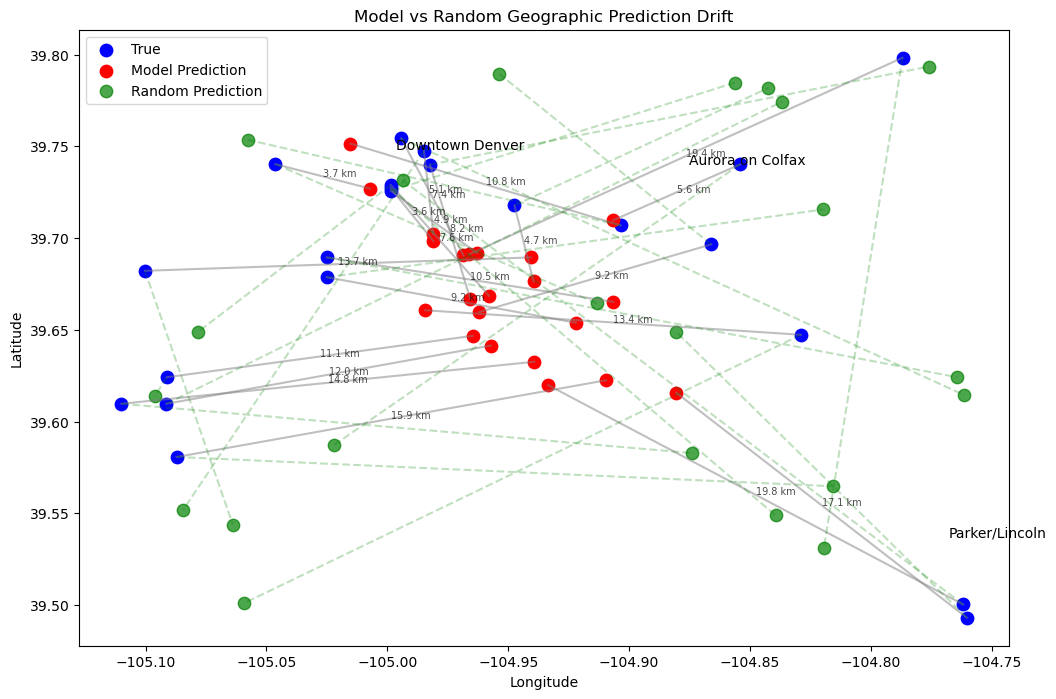

In [44]:
plt.figure(figsize=(12,8))

plt.text(
    -104.996583333333,
    39.74852777777778,
    "Downtown Denver"
)

plt.text(
    -104.875277777777,
    39.74022222222222,
    "Aurora on Colfax"
)
plt.text(
    -104.768055555555,
    39.53711111111111, 
    "Parker/Lincoln")

# TRUE LOCATIONS
plt.scatter(
    pred_df["longitude"],
    pred_df["latitude"],
    color="blue",
    label="True",
    s=80
)

# MODEL PREDICTIONS
plt.scatter(
    pred_df["pred_longitude"],
    pred_df["pred_latitude"],
    color="red",
    label="Model Prediction",
    s=80
)

# RANDOM PREDICTIONS
plt.scatter(
    pred_df["random_longitude"],
    pred_df["random_latitude"],
    color="green",
    label="Random Prediction",
    s=80,
    alpha=0.7
)

# MODEL LINES + ERROR LABELS
for _, row in pred_df.iterrows():

    # model prediction line
    plt.plot(
        [row["longitude"], row["pred_longitude"]],
        [row["latitude"], row["pred_latitude"]],
        color="gray",
        alpha=0.5
    )

    # midpoint for annotation
    mid_x = (
        row["longitude"] +
        row["pred_longitude"]
    ) / 2

    mid_y = (
        row["latitude"] +
        row["pred_latitude"]
    ) / 2

    # model error label
    plt.text(
        mid_x,
        mid_y,
        f"{row['error_km']:.1f} km",
        fontsize=7,
        alpha=0.7,
        color="black"
    )

# RANDOM LINES
for _, row in pred_df.iterrows():

    plt.plot(
        [row["longitude"], row["random_longitude"]],
        [row["latitude"], row["random_latitude"]],
        color="green",
        alpha=0.25,
        linestyle="dashed"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Model vs Random Geographic Prediction Drift")

plt.legend()

plt.savefig("test_random_vs_model.png", dpi=300)

plt.show()

In [ ]:
print("MODEL")
print(pred_df["error_km"].describe())

print("\nRANDOM")
print(pred_df["random_error_km"].describe())

In [ ]:
query = "taqueria mercado pho celulares"

predicted_coords = coord_model.predict([query])

pred_lat = predicted_coords[0][0]
pred_lon = predicted_coords[0][1]

print(pred_lat, pred_lon)

# Predict Possible Areas Based on Intersection Text Data
# using "Neighbors

In [ ]:
# grab the vectorizer to visualize
# vectorizer = model.named_steps["tfidf"]
vectorizer = coord_model.named_steps["tfidf"]

X_all_tfidf = vectorizer.transform(intersection_df["text_blob"])

In [ ]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(
    n_neighbors=5,
    metric="cosine"
)

nn_model.fit(X_all_tfidf)

In [ ]:
def find_linguistic_neighbors(text, intersection_df, vectorizer, nn_model, n_neighbors=5):
    text_vec = vectorizer.transform([text])

    distances, indices = nn_model.kneighbors(
        text_vec,
        n_neighbors=n_neighbors
    )

    results = intersection_df.iloc[indices[0]].copy()
    results["cosine_distance"] = distances[0]
    results["similarity"] = 1 - results["cosine_distance"]

    return results[
        [
            "intersection",
            "city",
            "latitude",
            "longitude",
            "similarity",
            "text_blob"
        ]
    ]

In [ ]:
def plot_knn_triangulation(knn_df, n, actual:tuple):
    knn_df = knn_df[:n]
    average = triangulate_mean(knn_df, n)
    plt.scatter(knn_df["longitude"], knn_df["latitude"],
           label = f"Top {n} Projected Points")
    plt.scatter(actual[0], actual[1], label = "Actual Intersection")
    plt.scatter(average[0], average[1], label = "Triangulation")
    plt.legend()
    plt.show()

In [ ]:
def triangulate_mean(knn_df, n):
    knn_df = knn_df[:n]
    knn_longitude_average = knn_df["longitude"].mean()
    knn_latitude_average = knn_df["latitude"].mean()
    return((knn_longitude_average, knn_latitude_average))

In [ ]:
# test a query on Grant
query_text = """
taco river autozone pho vietnamnese restaurant crawfish market pho
"""
query_point = (-105.025207, 39.694929) 

test_knn = find_linguistic_neighbors(
    query_text,
    intersection_df,
    vectorizer,
    nn_model,
    n_neighbors=5
)

In [ ]:
test_knn

In [ ]:
plot_knn_triangulation(test_knn, n= 2, actual = query_point)

In [ ]:
# take the top four closest in linguistic space
test_knn = test_knn[:3]

knn_longitude_average = test_knn["longitude"].mean()
knn_latitude_average = test_knn["latitude"].mean()

In [ ]:
plt.scatter(test_knn["longitude"], test_knn["latitude"],
           label = "Top Three Projected Points")
plt.scatter(query_point[0], query_point[1], label = "Actual Intersection")
plt.scatter(knn_longitude_average, knn_latitude_average, label = "Prediction")
plt.legend()
plt.show()

In [ ]:
# visualize the gram weights
X_test_tfidf = vectorizer.transform(X_test)
feature_names = vectorizer.get_feature_names_out()

# model for kmean space
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        lowercase=True,
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=5000
    ))
])

# for kmean clusters
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
feature_names

In [ ]:
# test looking at one row
row = X_test_tfidf[1]
weights = row.toarray()[0]

In [ ]:
tfidf_scores = list(zip(feature_names, weights))

In [ ]:
X_test

In [ ]:
preds = model.predict(X_test)

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
print(type(preds))

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    intersection_df["longitude"],   # x-axis
    intersection_df["latitude"],    # y-axis
    c=intersection_df["spatial_cluster"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Clusters by Intersection")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.scatter(coordinates["longitude"], coordinates["latitude"], color="orange")
ax.plot(platte_river_points["platte_long"], platte_river_points["platte_lat"])
ax.set_xlabel("Longitude", weight = "semibold")
ax.set_ylabel("Latitude", weight="semibold")
ax.set_title("Intersections in the Greater Denver Metro Area", weight="bold")
fig.show()